# Exploratory Data Analysis — Heart Disease Risk Screener

Dataset: UCI Cleveland Heart Disease (303 patients, 13 clinical features).
This notebook looks at the data BEFORE any encoding/scaling — it reads
`data/raw/cleveland_raw.csv`, the untouched file saved by `src/data_prep.py`.

Run `python src/data_prep.py` at least once before this notebook, so that
file exists.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "../report/figures/eda"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv("../data/raw/cleveland_raw.csv")
df["target"] = (df["target_raw"] > 0).astype(int)

CATEGORICAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
NUMERIC_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_raw,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


## 1. Basic shape and missing values

In [3]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values (only columns with any missing):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (303, 15)

Data types:
 age             int64
sex             int64
cp              int64
trestbps        int64
chol            int64
fbs             int64
restecg         int64
thalach         int64
exang           int64
oldpeak       float64
slope           int64
ca            float64
thal          float64
target_raw      int64
target          int64
dtype: object

Missing values (only columns with any missing):
ca      4
thal    2
dtype: int64


**Your notes:** which columns have missing values, and how many? This should match
what `ca` and `thal` show in `data_prep.py`'s printed output — if it doesn't, something
is inconsistent between this notebook and your pipeline.

## 2. Target class balance

target
0    164
1    139
Name: count, dtype: int64
target
0    0.541
1    0.459
Name: proportion, dtype: float64


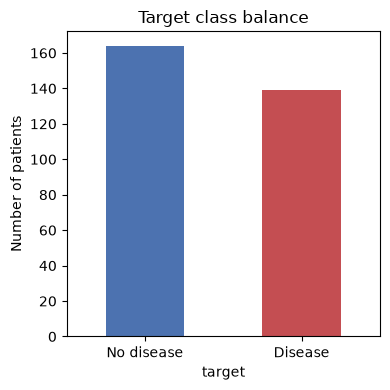

In [4]:
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3))

plt.figure(figsize=(4,4))
df["target"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0","#C44E52"])
plt.xticks([0,1], ["No disease","Disease"], rotation=0)
plt.ylabel("Number of patients")
plt.title("Target class balance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_balance.png", dpi=150)
plt.show()

**Your notes:** is the dataset roughly balanced or skewed toward one class? This matters
for why the brief asks for stratified splits and stratified cross-validation throughout.

## 3. Numeric feature summary and distributions

In [5]:
df[NUMERIC_COLS].describe().round(2)

,age,trestbps,chol,thalach,oldpeak
count,303.00,303.00,303.00,303.00,303.00
mean,54.44,131.69,246.69,149.61,1.04
std,9.04,17.60,51.78,22.88,1.16
min,29.00,94.00,126.00,71.00,0.00
25%,48.00,120.00,211.00,133.50,0.00
50%,56.00,130.00,241.00,153.00,0.80
75%,61.00,140.00,275.00,166.00,1.60
max,77.00,200.00,564.00,202.00,6.20


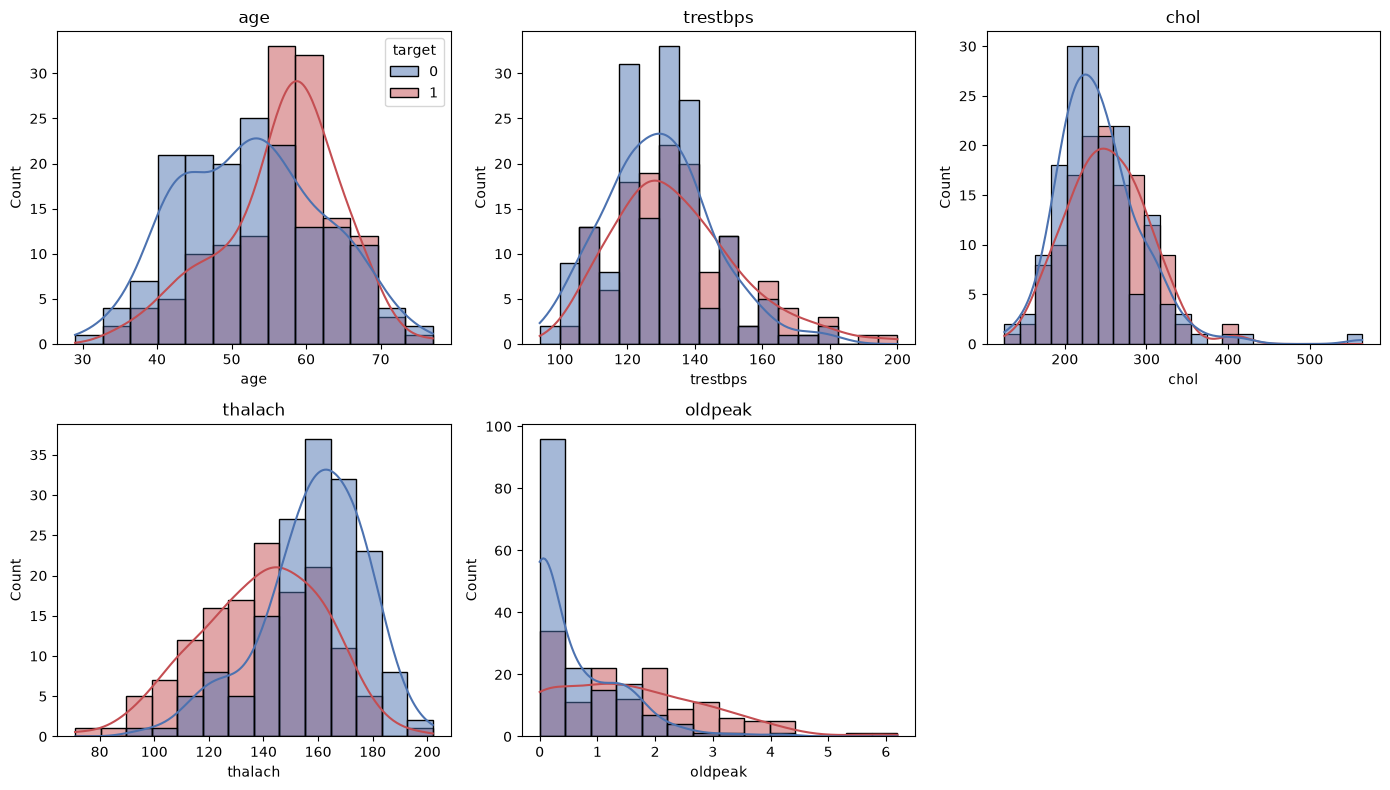

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), NUMERIC_COLS):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax,
                 palette=["#4C72B0","#C44E52"], legend=(col==NUMERIC_COLS[0]))
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/numeric_distributions.png", dpi=150)
plt.show()

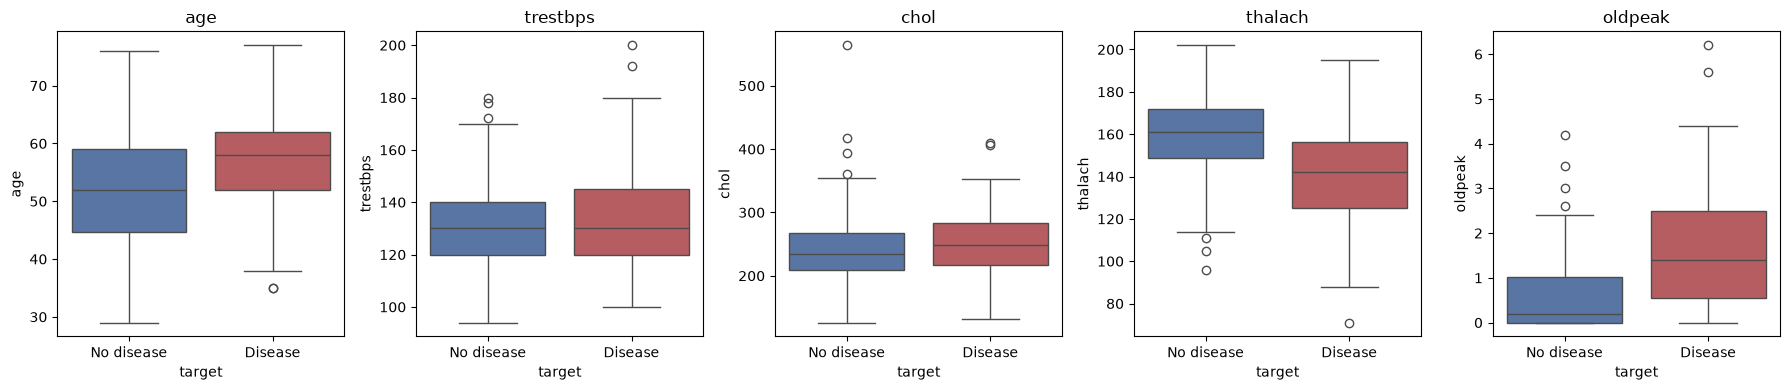

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, NUMERIC_COLS):
    sns.boxplot(data=df, x="target", y=col, hue="target",
                palette=["#4C72B0","#C44E52"], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No disease","Disease"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/numeric_boxplots.png", dpi=150)
plt.show()

**Your notes:** which numeric features look visibly different between the disease and
no-disease groups? Which look almost identical (and are therefore probably weak
predictors on their own)? Are there any outliers you should be aware of (e.g. an
unusually low or high value in `chol` or `trestbps`)?

## 4. Categorical features vs disease rate

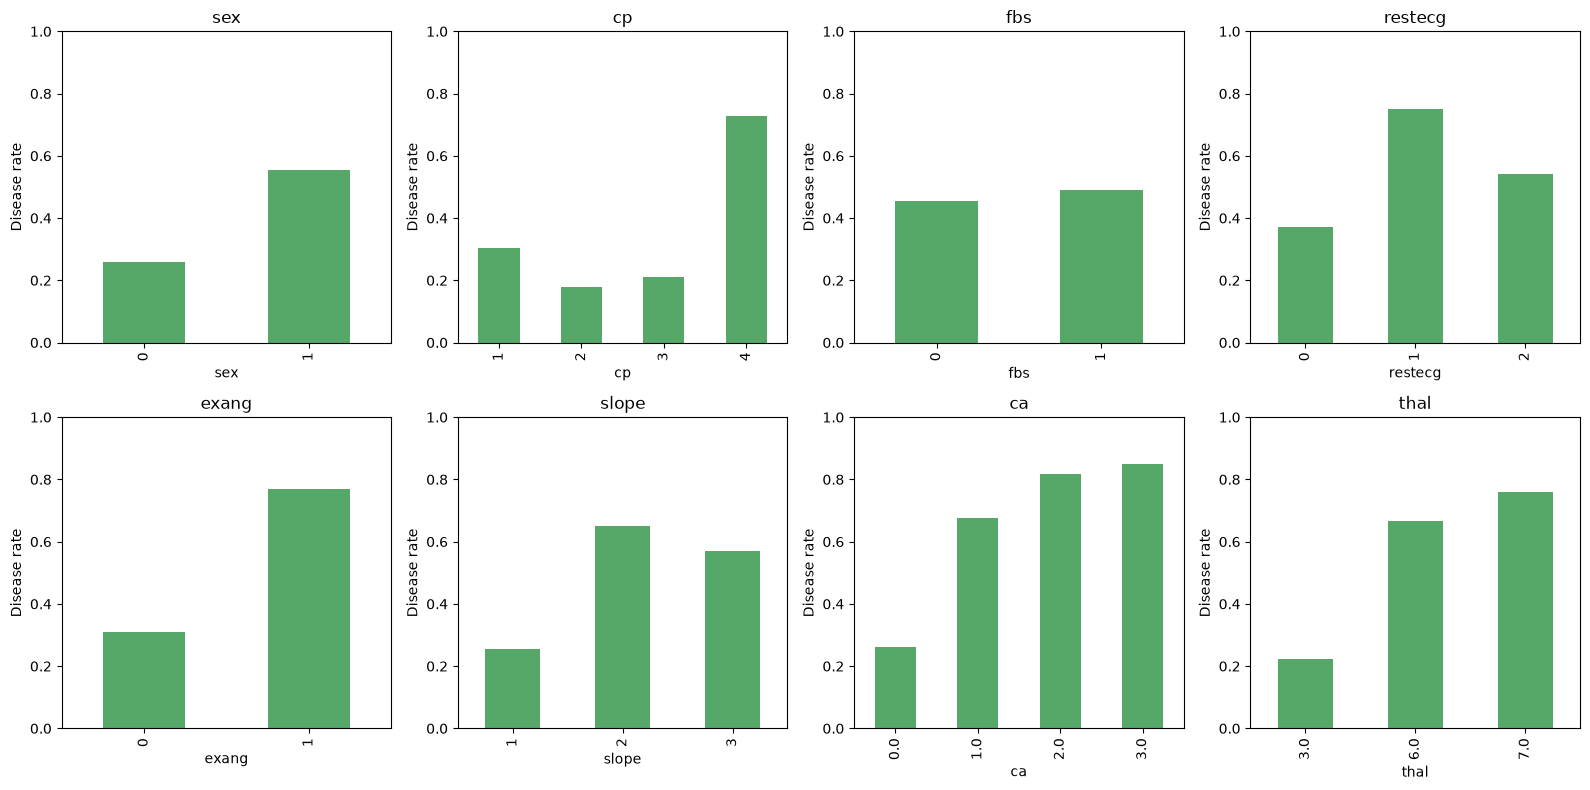

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), CATEGORICAL_COLS):
    rate = df.groupby(col)["target"].mean()
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_ylabel("Disease rate")
    ax.set_title(col)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/categorical_disease_rate.png", dpi=150)
plt.show()

**Your notes:** each bar shows the fraction of patients WITH that category who have
disease. Which categorical features show a big difference between their categories
(strong signal), and which are nearly flat across categories (weak signal)? `cp`
(chest pain type) and `thal` are worth a close look here.

## 5. Correlation between numeric features

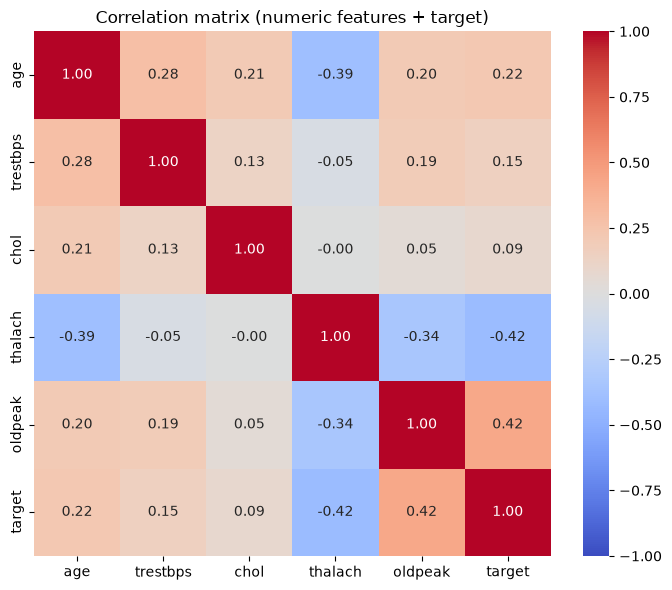

In [9]:
plt.figure(figsize=(7,6))
corr = df[NUMERIC_COLS + ["target"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

**Your notes:** are any two numeric features strongly correlated with each other
(which could mean redundant information)? Which numeric feature correlates most
strongly with the target?

## 6. Summary

Write 4-6 sentences here, in your own words, summarising what this EDA told you about
the dataset before modelling. This is the section your report's "Dataset and EDA" part
should be based on. Suggested points to cover:
- Class balance and what it means for evaluation choices (stratified CV, etc.)
- Which 2-3 features look most informative from the plots above
- What the missing-value pattern in `ca`/`thal` looks like and why it might matter
- Anything that surprised you or that you'd want to double-check
